<a href="https://colab.research.google.com/github/fvt1999pipe-eng/analisis_connectaTel/blob/main/S7_Version_Estudiante_Project_ConnectaTel_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
**usage**
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- tiene valores faltantes en las columnas de date, duration y length. 0,1% en date, 55,1% en duration y 44,7% en length
- Indica qué harías: ¿imputar, eliminar, ignorar?
- para este caso en date es minimo, los dejaria como nulos, y en el caso de duration y length, la tabla solo tiene informacion de uno o de otro, es decir que debo sumar los %, lo que me da que tenemos el 99,93% de los datos, para este caso tambien dejaria los valores faltante como nulos.

**users**
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- tiene valores faltantes en las columnas de city y churn_date, el 11,7% para city y 88,3% en churn_date
- Indica qué harías: ¿imputar, eliminar, ignorar?
- para este caso yo investigaria en caso de que se pudiera imputar. para churn_date crearia una nueva columna que me diga que usuarios estan activos o no, ya que la falta de valores es por q no han cancelado la linea

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
columnas_num = ["user_id","age"]
users[columnas_num].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` no aporta información real como estadística descriptiva porque es un identificador
- La columna `age` tiene datos imposibles, como -999, pero el mximo y los rangos se ven normales

In [ ]:
# explorar columnas numéricas de usage
columnas_num = ["id","user_id"]
usage[columnas_num].describe()

,id,user_id
count,40000.00000,40000.000000
mean,20000.50000,12002.405975
std,11547.14972,1157.279564
min,1.00000,10000.000000
25%,10000.75000,10996.000000
50%,20000.50000,12013.000000
75%,30000.25000,13005.000000
max,40000.00000,13999.000000


- Las columnas `id` y `user_id`  no aportan información real como estadística descriptiva porque son un identificador

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` tienes 3531 registors, tiene 7 valores unicos, donde la ciudad que mas datos tiene es la de bogota con 808 registros
- La columna `plan` tiene 4000 registors, 2 valores unicos, y el plan con mas registros es el plan basico

In [ ]:
# explorar columna categórica de usage
usage['type'].describe() # completa el código


count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` tiene 40000 registros, 2 obciones unicas, donde la que mas registros tiene es la de text


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- en la columna de age hay un sentinels = -999, ademas en city se identifico valores como (?) en vez de nombre de ciudades, fuera de esto, las columnas no presentan otras novedades evidentes
- ¿Qué acción tomarías?
- cambiaria el -999 por la mediana y cambiar (?) en city por nulos, de forma que quede estandar la informacion en las columnas

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'])

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] =  pd.to_datetime(usage['date'])

In [ ]:
# Revisar los años presentes en `reg_date` de users
users["reg_date"].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, tenemos registros erroneos con años del 2026, lo cual no es posible ya que la base esta hasta el 2024

In [ ]:
# Revisar los años presentes en `date` de usage
usage["date"].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, tenemos datos solo del 2024 y los nulos que ya sabiamos que eran el 0,1%

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- si, en la tabla de users tenemos años del 2026 los cuales no son posibles ya que no ha transcurrido ese año, en la tabla usage no hay datos imposibles, solo los 50 registros que estan nulos
- ¿Qué harías con ellas?
- para los datos que no han transcurrido, son solo 40, por el volumen de datos se puede optar por dejar como valor nulo

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users["age"].median()
users['age'] = users["age"].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users["city"] = users["city"].replace("?", pd.NA)

# Verificar cambios
users["city"].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [ ]:

# Marcar fechas futuras como NA para reg_date
users.loc[users["reg_date"].dt.year >= 2026, "reg_date"] =pd.NaT
# Verificar cambios
users["reg_date"].dt.year.value_counts()


2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
print(usage[usage["duration"].isna()]["type"].value_counts())

print(len(usage[usage["type"] == "text"]))

text    22076
Name: type, dtype: int64
22092


In [ ]:
# Verificación MAR en usage (Missing At Random) para length
print(usage[usage["length"].isna()]["type"].value_counts())

print(len(usage[usage["type"] == "call"]))

call    17896
Name: type, dtype: int64
17908


la conclusion es que los nulos no son al azar, estan determinados por el tipo de accion, si es un texto tienes largo del mensaje "length", pero no tiene duracion, y al revez, si es una llamada, tiene duracion "durtion", pero no tiene largo del mensaje

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id")[["is_text","is_call","duration"]].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={"is_text":"cant_mensajes","is_call":"cant_llamadas","duration":"cant_minutos_llamada"})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on ="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
column_num = ["age","cant_mensajes","cant_llamadas","cant_minutos_llamada"]
user_profile[column_num].describe()



,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize=True)*100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

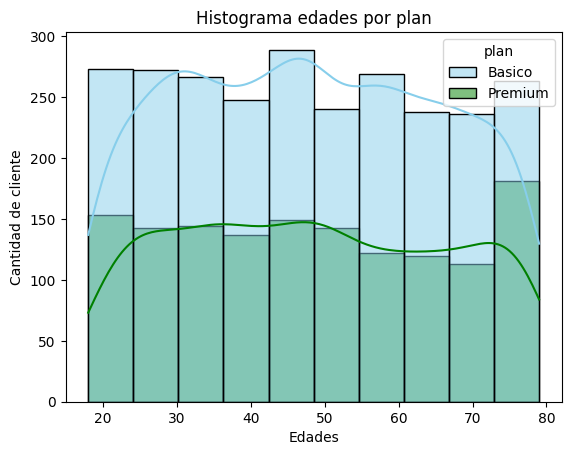

In [ ]:

# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x="age", bins=10, kde=True, hue="plan", palette=['skyblue','green'])
plt.xlabel('Edades')
plt.ylabel('Cantidad de cliente')
plt.title('Histograma edades por plan')

plt.show()


💡Insight: En todas las edades hay más clientes Básico que Premium (casi el doble). Premium tiene mayor proporción de clientes entre 73 y 79 años. Fuera de eso, no hay un patrón claro de edad por plan.

Distribución: Aproximadamente simétrica (casi uniforme) en ambos planes, sin sesgo marcado.

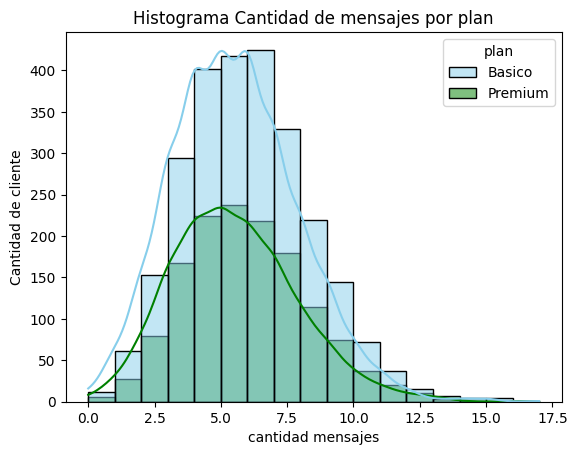

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x="cant_mensajes", bins=17, kde=True, hue="plan", palette=['skyblue','green'])
plt.xlabel('cantidad mensajes')
plt.ylabel('Cantidad de cliente')
plt.title('Histograma Cantidad de mensajes por plan')

plt.show()

💡Insight: Los usuarios de ambos planes suelen enviar entre 4 y 7 mensajes, con un pico cerca de 5–6. El plan Básico tiene más clientes en todos los rangos, pero el patrón de uso es el mismo en los dos planes.

Distribución: Levemente sesgada a la derecha: pocos clientes envían más de 10 mensajes, y eso forma una cola hacia la derecha.

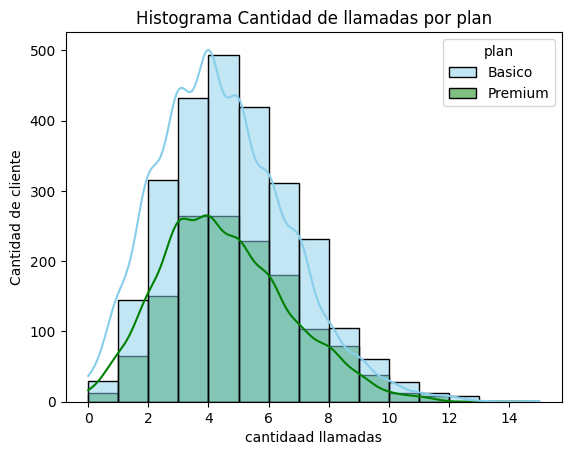

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x="cant_llamadas", bins=15, kde=True, hue="plan", palette=['skyblue','green'])
plt.xlabel('cantidaad llamadas')
plt.ylabel('Cantidad de cliente')
plt.title('Histograma Cantidad de llamadas por plan')

plt.show()

💡Insight: En ambos planes la mayoría de los usuarios hace entre 3 y 6 llamadas, con un pico cerca de 4. El plan Básico tiene más clientes en todos los rangos, pero el patrón de uso es el mismo en los dos planes.

Distribución: Sesgada a la derecha. Pocos clientes hacen más de 9 llamadas (hasta unas 14), lo que forma una cola hacia la derecha.

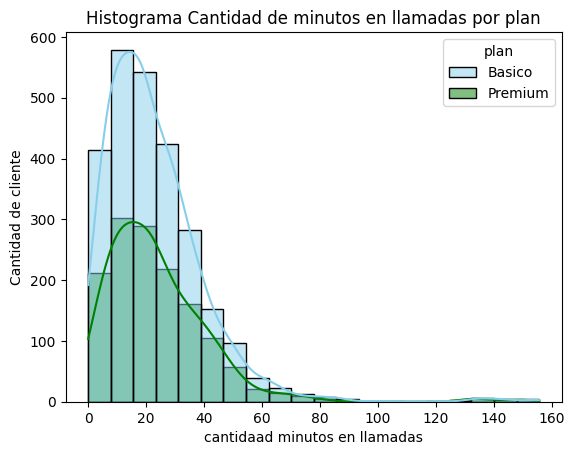

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x="cant_minutos_llamada", bins=20, kde=True, hue="plan", palette=['skyblue','green'])
plt.xlabel('cantidaad minutos en llamadas')
plt.ylabel('Cantidad de cliente')
plt.title('Histograma Cantidad de minutos en llamadas por plan')

plt.show()

💡Insight: La mayoría de los usuarios de ambos planes habla entre 8 y 30 minutos, con un pico cerca de 15. Básico tiene más clientes en todos los rangos, pero el patrón de uso es el mismo; solo unos pocos casos atípicos superan los 120 minutos.

Distribución: Claramente sesgada a la derecha: la cola larga se extiende hasta unos 155 minutos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

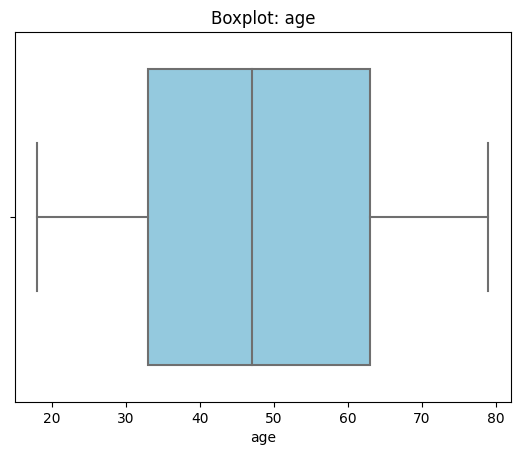

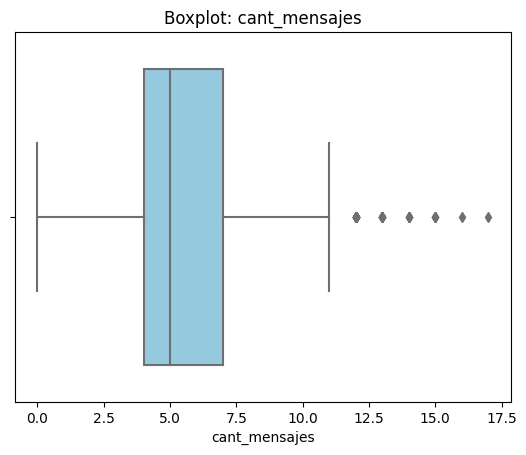

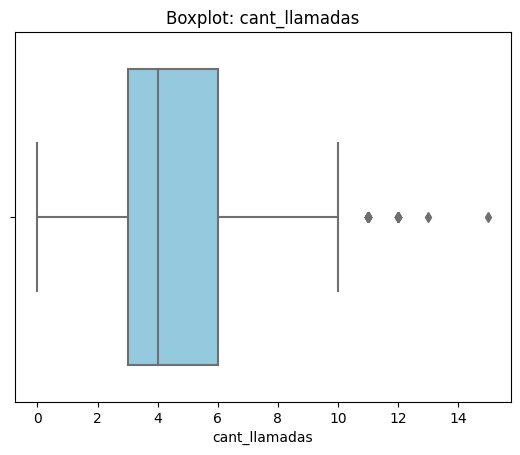

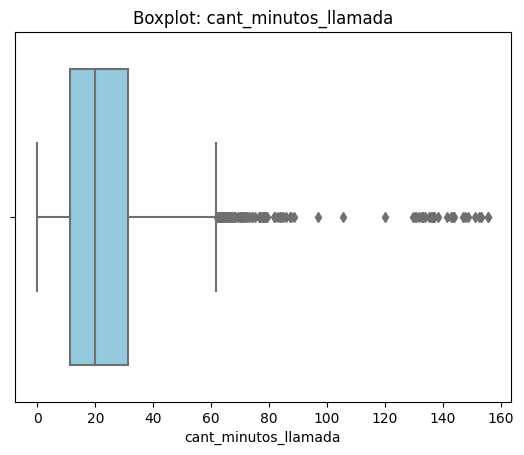

In [ ]:
# Visualizando usando BoxPlot

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.show()



💡Insights:
-Age: No presenta outliers; todos los datos están entre 18 y 79 años.
-cant_mensajes: Presenta outliers: clientes con 12 a 17 mensajes, por encima del límite superior (~11).
-cant_llamadas: Presenta outliers: clientes con 11, 12, 13 y 15 llamadas, por encima del límite superior (10).
-cant_minutos_llamada: Presenta muchos outliers por encima de ~62 minutos, con casos extremos entre 120 y 155 minutos.

In [ ]:

# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    print(f'limites de {col}')
    extremo_inf = Q1 - 1.5 * IQR
    extremo_sup = Q3 + 1.5 * IQR
    print(f'limite inferior: {extremo_inf}')
    print(f'limite superior: {extremo_sup}')
    print()




limites de cant_mensajes
limite inferior: -0.5
limite superior: 11.5

limites de cant_llamadas
limite inferior: -1.5
limite superior: 10.5

limites de cant_minutos_llamada
limite inferior: -19.322500000000005
limite superior: 61.8575



In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:

cant_mensajes: límite superior de 11.5 y máximo de 17. Los valores altos son posibles y realistas, así que se mantienen.
cant_llamadas: límite superior de 10.5 y máximo de 15. Tampoco se trata de errores; se mantienen.
cant_minutos_llamada: límite superior de ~61.9 y máximo de 155.7. La diferencia es mayor, pero siguen siendo valores posibles de clientes con alto consumo; se mantienen.

Decisión: no se reemplazan ni se eliminan los outliers. No son errores de captura: reflejan el comportamiento real de clientes intensivos, que es información valiosa para comparar los planes. Además, los límites inferiores son negativos, así que no hay outliers por debajo.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.


**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos


In [ ]:
# Crear columna grupo_uso
def classify_users(row):
    call = row["cant_llamadas"]
    mens = row["cant_mensajes"]
    if call < 5 and mens < 5:
        return "Bajo uso"
    elif call < 10 and mens < 10:
         return "Uso medio"
    else:
        return "Alto uso"

user_profile["grupo_uso"] = user_profile.apply(classify_users, axis = 1)



In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def classify_age(row):
    age = row["age"]
    if age < 30 :
        return "Joven"
    elif age < 60 :
         return "Adulto"
    else:
        return "Adulto Mayor"

user_profile["grupo_edad"] = user_profile.apply(classify_age, axis = 1)


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

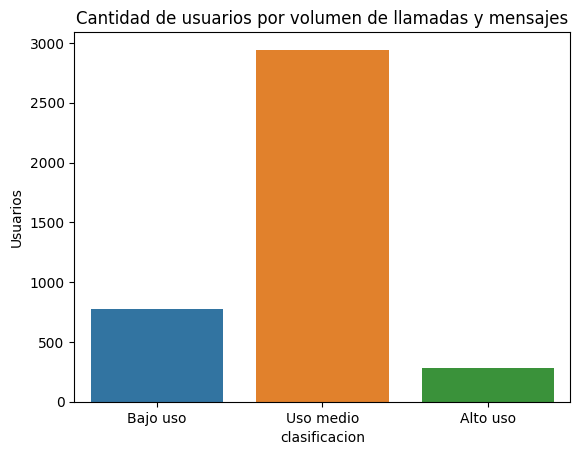

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x="grupo_uso", order=["Bajo uso", "Uso medio", "Alto uso"])
plt.title("Cantidad de usuarios por volumen de llamadas y mensajes")
plt.xlabel("clasificacion")
plt.ylabel("Usuarios")
plt.show()

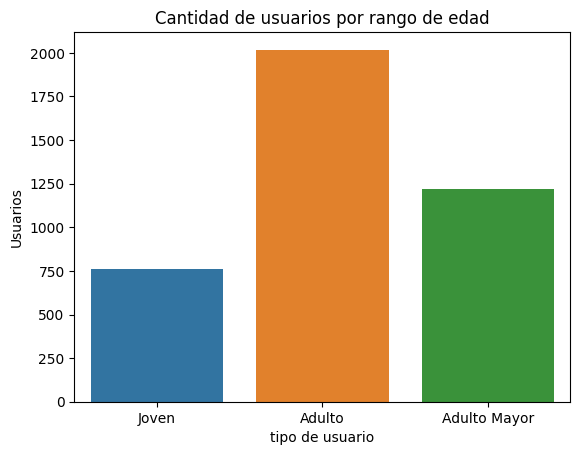

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x="grupo_edad", order=["Joven", "Adulto", "Adulto Mayor"])
plt.title("Cantidad de usuarios por rango de edad")
plt.xlabel("tipo de usuario")
plt.ylabel("Usuarios")
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

⚠️ **Problemas detectados en los datos**
- **`age`**: 55 registros (1,4%) con el sentinel `-999`, que distorsionaban la media (33,7 frente a 48,1 real). Se reemplazaron por la mediana (47 años).
- **`city`**: 469 nulos (11,7%) más 96 registros con `"?"` (2,4%), en total 565 usuarios (14,1%) sin ciudad válida. Los `"?"` se estandarizaron como nulos.
- **`reg_date`**: 40 registros (1,0%) con año 2026, imposible porque los datos llegan hasta 2024. Se marcaron como `NaT`.
- **`churn_date`**: 3.534 nulos (88,4%). No es un error: corresponden a clientes activos. Solo 466 usuarios (11,6%) cancelaron.
- **`date` (usage)**: 50 nulos (0,1%), un impacto mínimo, por lo que se dejaron como nulos.
- **`duration` / `length`**: 55,2% y 44,7% de nulos que no son aleatorios. Dependen del tipo de registro: las llamadas no tienen longitud y los mensajes no tienen duración.
- **1 usuario** no tiene ningún registro de uso.


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

🔍 **Segmentos por Edad**
- La edad se distribuye de forma casi uniforme entre 18 y 79 años en ambos planes, sin un sesgo marcado.
- El segmento **Adulto (30–59)** es el más grande porque abarca el rango de edad más amplio. **Adulto Mayor (60+)** es el segundo, y **Joven (<30)** el más pequeño.
- La edad **no determina** el plan ni el volumen de uso: todos los grupos muestran patrones de consumo similares. La única diferencia visible es una mayor proporción de clientes Premium entre los 73 y 79 años.



📊 **Segmentos por Nivel de Uso**
- El cliente típico es de consumo bajo: una mediana de **5 mensajes, 4 llamadas y 19,8 minutos**.
- La mayoría se ubica en **Uso medio**, seguido de **Bajo uso**. El segmento **Alto uso** es minoritario.
- Básico y Premium tienen **el mismo patrón de consumo**. Los clientes Premium no usan más el servicio que los Básico.
- El consumo real está muy por debajo de lo incluido en los planes:
  - En minutos, la media es de 23 min frente a 100 (Básico) y 600 (Premium). Incluso el máximo (155,7 min) no alcanza ni el 26% del Premium.
  - En mensajes, el máximo es 17 frente a 100 (Básico) y 500 (Premium).


- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

📌 **Segmentos más valiosos**
- **Alto uso**: son los clientes que más utilizan el servicio y los únicos que pueden generar ingresos por consumo adicional en el plan Básico. Son la base natural para ventas de mayor valor (upselling).
- **Clientes Premium (35,1%)**: pagan $25 frente a $12 del Básico, más del doble, sin consumir más. Hoy son el segmento más rentable, pero también el de **mayor riesgo de cancelación** si perciben que pagan por algo que no usan.


- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

🚨 **Patrones de uso extremo (outliers)**
- **Mensajes**: clientes con 12 a 17 mensajes (límite IQR: 11,5).
- **Llamadas**: clientes con 11 a 15 llamadas (límite IQR: 10,5).
- **Minutos**: muchos casos sobre 62 minutos, y los extremos llegan a 120–155 minutos.
- No parecen errores de registro ni fraude: son valores posibles, sin negativos y con una cola continua. Representan **clientes intensivos reales**, por eso se mantuvieron en el análisis.
- Implicación: existe un grupo pequeño con necesidades diferentes. Si están en el plan Básico, son los únicos que podrían superar los 100 minutos y pagar excedentes.
➡️ Esto sugiere que **los planes actuales están sobredimensionados** frente al uso real. La diferencia entre Básico y Premium se basa en cantidades que casi ningún cliente usa, así que el plan contratado no refleja el comportamiento del cliente.


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

💡 **Recomendaciones**
- **Crear un plan de entrada más económico** (por ejemplo, 50 minutos y 50 mensajes) para el segmento Bajo uso, que es la mayoría de clientes. Así se captan clientes sensibles al precio sin canibalizar ingresos.
- **Rediseñar el Premium** para diferenciarlo por valor y no por volumen: más datos (GB), beneficios o servicios adicionales, en lugar de minutos que nadie consume.
- **Campaña de retención para clientes Premium de bajo uso**: ofrecerles un ajuste de plan o beneficios antes de que cancelen por percibir que pagan de más.
- **Oferta dirigida al segmento Alto uso del plan Básico**: un plan intermedio o un paquete de minutos adicionales que se adapte a su consumo.
- **Mejorar la calidad de captura de datos**: validar la edad, la ciudad y las fechas de registro en el origen (14% sin ciudad) para poder segmentar por país (México y Colombia) con confianza.
- **Siguiente análisis**: incorporar el consumo de datos (GB), que no está en `usage`, y cruzar el uso con la cancelación (`churn_date`) para confirmar si el bajo uso predice las cancelaciones.


✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- **`age`**: 55 registros (1,4%) con el sentinel `-999`, que bajaban la media a 33,7 años (la real es 48,1). Se reemplazaron por la mediana (47).
- **`city`**: 469 nulos (11,7%) más 96 valores `"?"` (2,4%), en total 565 usuarios (14,1%) sin ciudad válida. Los `"?"` se convirtieron en nulos.
- **`reg_date`**: 40 registros (1,0%) con año 2026, imposible porque los datos llegan hasta 2024. Se marcaron como `NaT`.
- **`churn_date`**: 3.534 nulos (88,4%). No es un error: corresponden a clientes activos. Solo 466 usuarios (11,6%) cancelaron.
- **`usage`**: 50 fechas nulas (0,1%). Los nulos en `duration` (55,2%) y `length` (44,7%) dependen del tipo de registro (llamada o mensaje), así que se dejaron como nulos.



🔍 **Segmentos por Edad**
- La edad se distribuye de forma casi uniforme entre 18 y 79 años. **Adulto (30–59)** es el grupo más grande, seguido de **Adulto Mayor (60+)** y **Joven (<30)**.
- La edad **no determina** el volumen de uso ni el plan. Todos los grupos consumen de forma similar, y la única diferencia visible es una mayor proporción de clientes Premium entre los 73 y 79 años.



📊 **Segmentos por Nivel de Uso**
- El cliente típico consume poco: una mediana de **5 mensajes, 4 llamadas y 19,8 minutos**. La mayoría está en **Uso medio**, seguido de **Bajo uso**, y **Alto uso** es minoritario.
- Básico y Premium tienen **el mismo patrón de consumo**. Premium cuesta más del doble ($25 frente a $12) sin que sus clientes usen más el servicio.
- El consumo está muy por debajo de lo incluido: la media es de 23 minutos frente a 100 (Básico) y 600 (Premium), y el máximo de mensajes es 17 frente a 100 y 500.
- **Outliers**: hay clientes con más de 11 mensajes, más de 10 llamadas y más de 62 minutos, con casos de hasta 155 minutos. Son valores posibles y continuos, así que no indican fraude ni errores: son **clientes intensivos reales**.
- **Segmentos más valiosos**: los clientes **Premium**, porque generan más ingresos por usuario, aunque tienen riesgo de cancelar al pagar por algo que no usan; y los de **Alto uso**, porque son los únicos que podrían superar los 100 minutos del Básico y son la base para ofrecerles un plan superior.



➡️ Esto sugiere que **los planes actuales están sobredimensionados** frente al uso real: la diferencia entre Básico y Premium se basa en volúmenes que casi ningún cliente consume, por lo que el plan contratado no refleja el comportamiento del cliente.

💡 **Recomendaciones**
- **Crear un plan de entrada más económico** (por ejemplo, 50 minutos y 50 mensajes) para los clientes de Bajo uso, que son una gran parte de la base.
- **Rediseñar el Premium** para diferenciarlo por valor (más GB, beneficios, servicios adicionales) y no por minutos que nadie usa.
- **Retener a los clientes Premium de bajo uso** con un ajuste de plan o beneficios, antes de que cancelen por sentir que pagan de más.
- **Ofrecer a los clientes de Alto uso del plan Básico** un plan intermedio o un paquete de minutos adicionales.
- **Mejorar la calidad de los datos en el origen** (edad, ciudad, fechas) para poder segmentar por país (México y Colombia) y cruzar el uso con las cancelaciones en próximos análisis.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`